In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import scipy.stats as stats

In [43]:
df = pd.read_csv("Health Insurance Dataset.csv")

# Part I: Univariate and Bivariate Statistical Analysis and Visualization

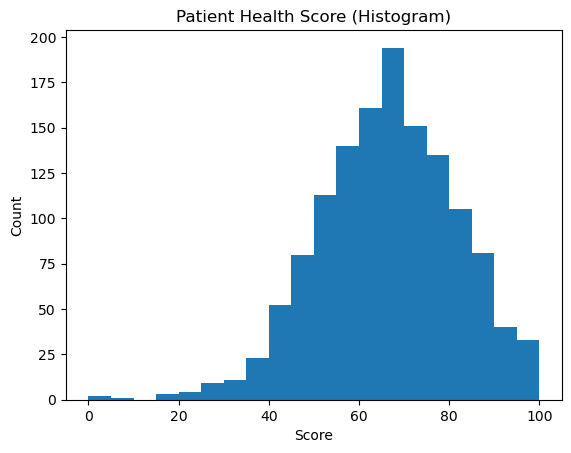

In [44]:
# Patient Health Score histogram (quantitative/numeric)
plt.figure()
plt.hist(df["score"].dropna(), bins=20)
plt.title("Patient Health Score (Histogram)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

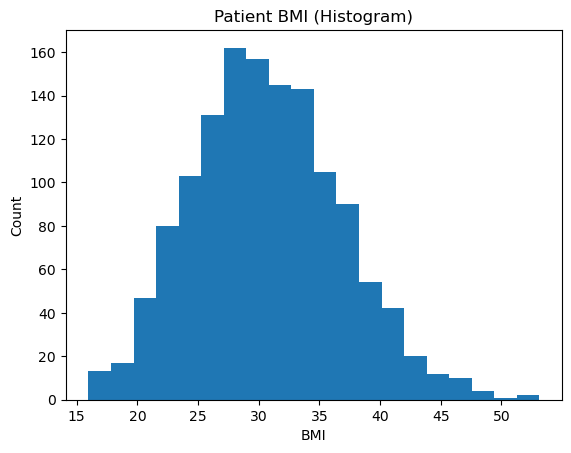

In [45]:
# Patient BMI histogram (quantitative/numeric)
plt.figure()
plt.hist(df["bmi"].dropna(), bins=20)
plt.title("Patient BMI (Histogram)")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

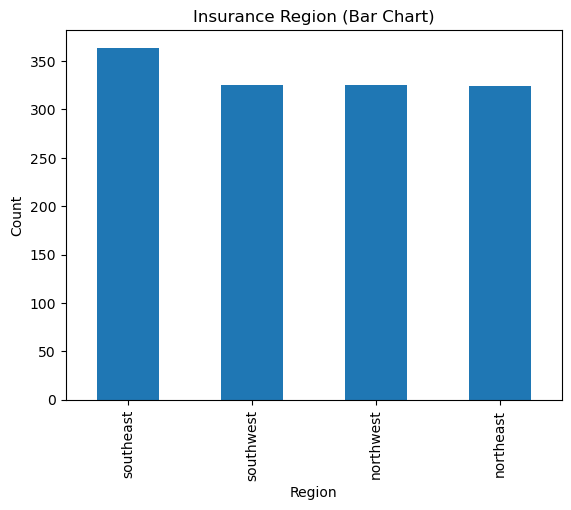

In [46]:
# Insurance Region Bar Chart (qualitative/categorical)

plt.figure()
df["region"].value_counts().plot(kind="bar")
plt.title("Insurance Region (Bar Chart)")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

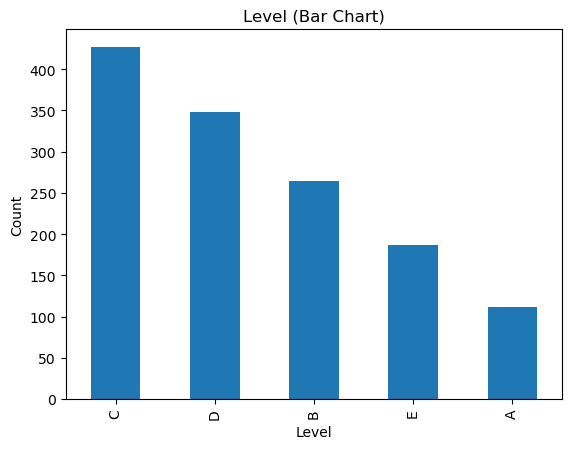

In [47]:
# Insurance Level Bar Chart (qualitative/categorical)

plt.figure()
df["Level"].value_counts().plot(kind="bar")
plt.title("Level (Bar Chart)")
plt.xlabel("Level")
plt.ylabel("Count")
plt.show()

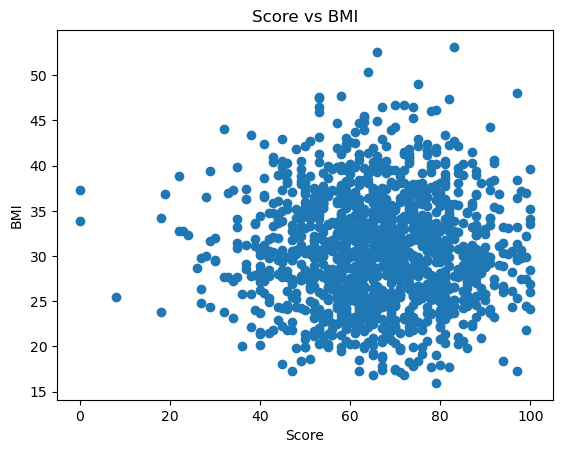

In [48]:
#Score vs BMI Scatterplot (Bivariate)

plt.figure()
plt.scatter(df["score"], df["bmi"])
plt.title("Score vs BMI")
plt.xlabel("Score")
plt.ylabel("BMI")
plt.show()

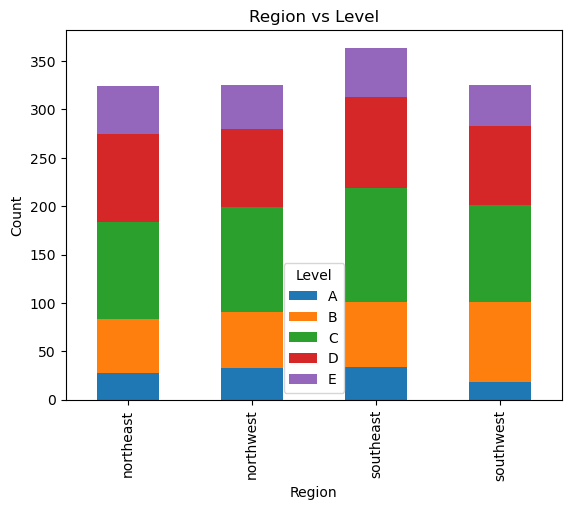

In [49]:
#Region vs Level Stacked Bar Chart(Bivariate)

ct = pd.crosstab(df["region"], df["Level"])
ct.plot(kind="bar", stacked=True)
plt.title("Region vs Level")
plt.xlabel("Region")
plt.ylabel("Count")
plt.legend(title="Level")
plt.show()

In [57]:
#Provide decriptive statistics for selected quantitative variables

num_cols = df[["score", "bmi"]]
desc_stats = num_cols.describe()
variance = num_cols.var()

print(desc_stats)
print("\nVariance:\n", variance)

             score          bmi
count  1338.000000  1338.000000
mean     65.967115    30.663987
std      15.235684     6.098063
min       0.000000    15.960000
25%      56.250000    26.296250
50%      66.000000    30.400000
75%      77.000000    34.693750
max     100.000000    53.130000

Variance:
 score    232.126068
bmi       37.186374
dtype: float64


In [52]:
#Get counts and percentages by category

cat_cols = ["region", "Level"] 

for c in cat_cols:
    counts = df[c].value_counts(dropna=False)
    perc = df[c].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({"count": counts, "percent": perc.round(2)})
    print("\n", c)
    print(summary)


 region
           count  percent
region                   
southeast    364    27.20
southwest    325    24.29
northwest    325    24.29
northeast    324    24.22

 Level
       count  percent
Level                
C        427    31.91
D        348    26.01
B        264    19.73
E        187    13.98
A        112     8.37


Part II: Parametric Statistical Testing

In [60]:
#run the parametric test and provide the output 

df = pd.read_csv("Health Insurance Dataset.csv")

r, p = pearsonr(df["bmi"], df["score"])

print("Pearson correlation (r):", r)
print("p-value:", p)

Pearson correlation (r): -0.00846179897534109
p-value: 0.757140714961157


In [64]:
#perform the Chi-Square Test of Independence

contingency = pd.crosstab(df["region"], df["Level"])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 13.933419380434769
p-value: 0.3049802071760144
Degrees of freedom: 12
